# Project Walkthrough


In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.utils import load_yaml

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [19]:
cfg = load_yaml("config/default.yaml")
project_cfg = cfg["project"]

processed_dir = Path(project_cfg["processed_dir"])
predictions_dir = Path(project_cfg["predictions_dir"])
outputs_tables_dir = Path(project_cfg["outputs_tables_dir"])
outputs_figures_dir = Path(project_cfg["outputs_figures_dir"])
report_dir = Path(project_cfg["outputs_reports_dir"]) / "model_report"

TARGET_CANDIDATES = ["y_excess", "y_raw", "y_rank", "y_class"]
ID_COLUMNS = {
    "ticker", "quarter", "company", "raw_path", "call_date", "entry_date", "exit_date", "split",
    "y_raw", "y_excess", "y_rank", "y_class", "y_class_label", "benchmark_return", "spy_return"
}

def read_parquet_if_exists(path: Path) -> pd.DataFrame | None:
    return pd.read_parquet(path) if path.exists() else None

def read_csv_if_exists(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None

def infer_feature_columns(df: pd.DataFrame) -> list[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [
        col for col in numeric_cols
        if col not in ID_COLUMNS and not (col.endswith("_return") or col.endswith("_cum_return"))
    ]

def choose_target_column(df: pd.DataFrame) -> str | None:
    for col in TARGET_CANDIDATES:
        if col in df.columns and df[col].notna().any():
            return col
    return None

def display_section(title: str, text: str = "") -> None:
    body = f"## {title}"
    if text:
        body += f"\n\n{text}"
    display(Markdown(body))

def plot_table_heatmap(corr_df: pd.DataFrame, title: str, figsize=(10, 8), cmap="coolwarm") -> None:
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr_df.values, cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

def show_image_if_exists(path: Path, title: str) -> None:
    if not path.exists():
        display(Markdown(f"### {title}\n\n`{path}` not found."))
        return
    display(Markdown(f"### {title}\n\nSource: `{path}`"))
    display(Image(filename=str(path)))

modeling_df = read_parquet_if_exists(processed_dir / "modeling_table.parquet")
features_df = read_parquet_if_exists(processed_dir / "features.parquet")
split_df = read_parquet_if_exists(processed_dir / "split_table.parquet")

prediction_files = sorted(predictions_dir.glob("*_predictions.parquet"))
prediction_map = {fp.stem.replace("_predictions", ""): pd.read_parquet(fp) for fp in prediction_files}

model_metrics_df = read_csv_if_exists(outputs_tables_dir / "model_metrics.csv")
backtest_summary_df = read_csv_if_exists(outputs_tables_dir / "backtest_summary.csv")
backtest_detail_df = read_csv_if_exists(outputs_tables_dir / "backtest_detail.csv")
model_comparison_df = read_csv_if_exists(report_dir / "model_comparison_summary.csv")
model_long_short_df = read_csv_if_exists(report_dir / "model_long_short_summary.csv")
model_event_df = read_csv_if_exists(report_dir / "model_event_backtest_summary.csv")

if modeling_df is None:
    raise FileNotFoundError("`data/processed/modeling_table.parquet` not found. Run the pipeline first.")

if "call_date" in modeling_df.columns:
    modeling_df["call_date"] = pd.to_datetime(modeling_df["call_date"])
if "entry_date" in modeling_df.columns:
    modeling_df["entry_date"] = pd.to_datetime(modeling_df["entry_date"])
if "exit_date" in modeling_df.columns:
    modeling_df["exit_date"] = pd.to_datetime(modeling_df["exit_date"])

feature_columns = infer_feature_columns(modeling_df)
target_col = choose_target_column(modeling_df)
train_df = modeling_df.loc[modeling_df["split"] == "train"].copy() if "split" in modeling_df.columns else modeling_df.copy()
test_df = modeling_df.loc[modeling_df["split"] == "test"].copy() if "split" in modeling_df.columns else pd.DataFrame()

display_section(
    "Loaded Artifacts",
    f"Processed rows: **{len(modeling_df)}**  \n"
    f"Feature columns: **{len(feature_columns)}**  \n"
    f"Active target column: **{target_col or 'None found'}**  \n"
    f"Prediction files found: **{len(prediction_map)}**"
)

## Loaded Artifacts

Processed rows: **131**  
Feature columns: **15**  
Active target column: **y_excess**  
Prediction files found: **12**

## 1. Processed Dataset Overview

This section gives a quick sense of the final modeling table that is saved to disk and later reused by modeling and backtesting.

In [20]:
overview = pd.DataFrame(
    {
        "metric": [
            "n_rows",
            "n_tickers",
            "n_quarters",
            "call_date_min",
            "call_date_max",
            "n_feature_columns",
            "target_column",
            "train_rows",
            "test_rows",
        ],
        "value": [
            len(modeling_df),
            modeling_df["ticker"].nunique() if "ticker" in modeling_df.columns else np.nan,
            modeling_df["quarter"].nunique() if "quarter" in modeling_df.columns else np.nan,
            modeling_df["call_date"].min() if "call_date" in modeling_df.columns else np.nan,
            modeling_df["call_date"].max() if "call_date" in modeling_df.columns else np.nan,
            len(feature_columns),
            target_col,
            len(train_df),
            len(test_df),
        ],
    }
)

display(overview)

if "split" in modeling_df.columns:
    display_section("Split Counts")
    display(modeling_df["split"].value_counts(dropna=False).rename_axis("split").to_frame("count"))

display_section("Sample Rows")
display(modeling_df[[col for col in ["ticker", "quarter", "call_date", *feature_columns[:6], target_col, "split"] if col is not None and col in modeling_df.columns]].head(10))

,metric,value
0,n_rows,131
1,n_tickers,14
2,n_quarters,13
3,call_date_min,2024-01-12 00:00:00
4,call_date_max,2026-04-14 00:00:00
5,n_feature_columns,15
6,target_column,y_excess
7,train_rows,84
8,test_rows,47


## Split Counts

,count
split,
train,84
test,47


## Sample Rows

,ticker,quarter,call_date,overall_sentiment_score,ceo_cfo_consistency,analyst_sentiment_score,reactive_sentiment_score,guidance_net_score,reactive_topic_ratio,y_excess,split
0,AMD,Q4-2023,2024-01-30,0.7200,0.2400,-0.0800,-0.1800,0.5000,0.3333,-0.0121,train
1,AMD,Q1-2024,2024-04-30,0.6200,0.2600,-0.1200,-0.1800,0.2500,0.3846,0.0312,train
2,AMD,Q2-2024,2024-07-30,0.7200,0.1900,0.0800,-0.1200,0.3333,0.3750,-0.0511,train
3,AMD,Q3-2024,2024-10-29,0.7200,0.1900,-0.1800,-0.1200,0.3333,0.0909,-0.0426,train
4,AMD,Q4-2024,2025-02-04,0.7200,0.2400,-0.1800,-0.1200,0.3333,0.0000,-0.0012,train
5,AMD,Q1-2025,2025-05-06,0.6200,0.2400,-0.1200,-0.1800,0.2000,0.0625,0.1259,train
6,AMD,Q2-2025,2025-08-05,0.6200,0.2400,-0.0800,-0.1200,0.2000,0.3810,0.1114,test
7,AMD,Q3-2025,2025-11-04,0.7800,0.2900,0.0800,-0.0500,0.2500,0.3077,0.0014,test
8,AMD,Q4-2025,2026-02-03,0.7800,0.2600,-0.0800,-0.0500,0.2500,0.5000,0.0585,test
9,AVGO,Q1-2024,2024-03-07,0.6200,0.3400,0.0800,-0.0500,-0.1667,0.4615,-0.0554,train


## 2. Feature Snapshot

A compact statistical summary helps readers understand the range and scale of each engineered feature before looking at correlations.

,mean,std,min,median,max
analyst_sentiment_score,-0.0625,0.0862,-0.1800,-0.0800,0.1800
avg_risk_sentiment,-0.5469,0.1038,-0.7820,-0.5570,-0.2875
ceo_cfo_consistency,0.1631,0.0855,0.0200,0.1500,0.3600
ext_macd,0.0047,0.0254,-0.0557,0.0051,0.0868
ext_mean_return_5d,0.0031,0.0109,-0.0229,0.0045,0.0242
ext_volume_adv20,1.9460,0.6893,0.7940,1.8547,4.3154
guidance_delta,-0.0139,0.3687,-1.0500,0.0000,1.0000
guidance_net_score,0.2004,0.3730,-0.8000,0.2500,0.8000
new_risk_flag,0.8333,0.3749,0.0000,1.0000,1.0000
new_theme_ratio,0.2163,0.1620,0.0000,0.2265,0.5000


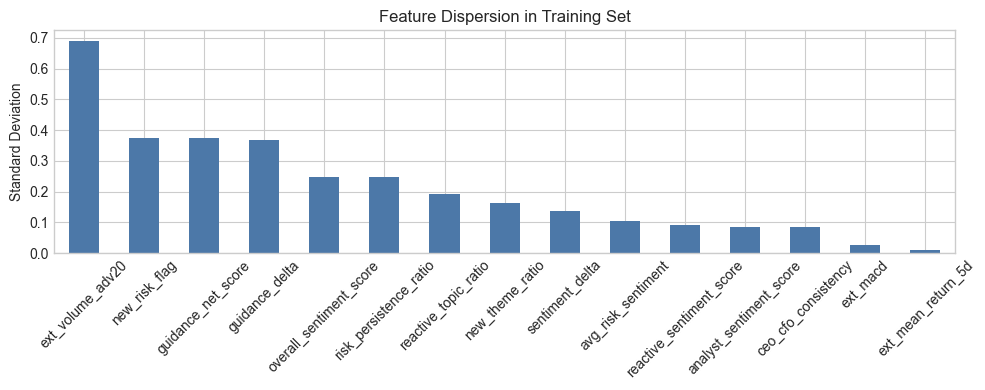

In [21]:
feature_summary = train_df[feature_columns].agg(["mean", "std", "min", "median", "max"]).T.sort_index()
display(feature_summary)

fig, ax = plt.subplots(figsize=(10, 4))
train_df[feature_columns].std().sort_values(ascending=False).plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Feature Dispersion in Training Set")
ax.set_ylabel("Standard Deviation")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature-to-Feature Correlation

This view highlights redundancy and clusters of features that may be telling similar stories.

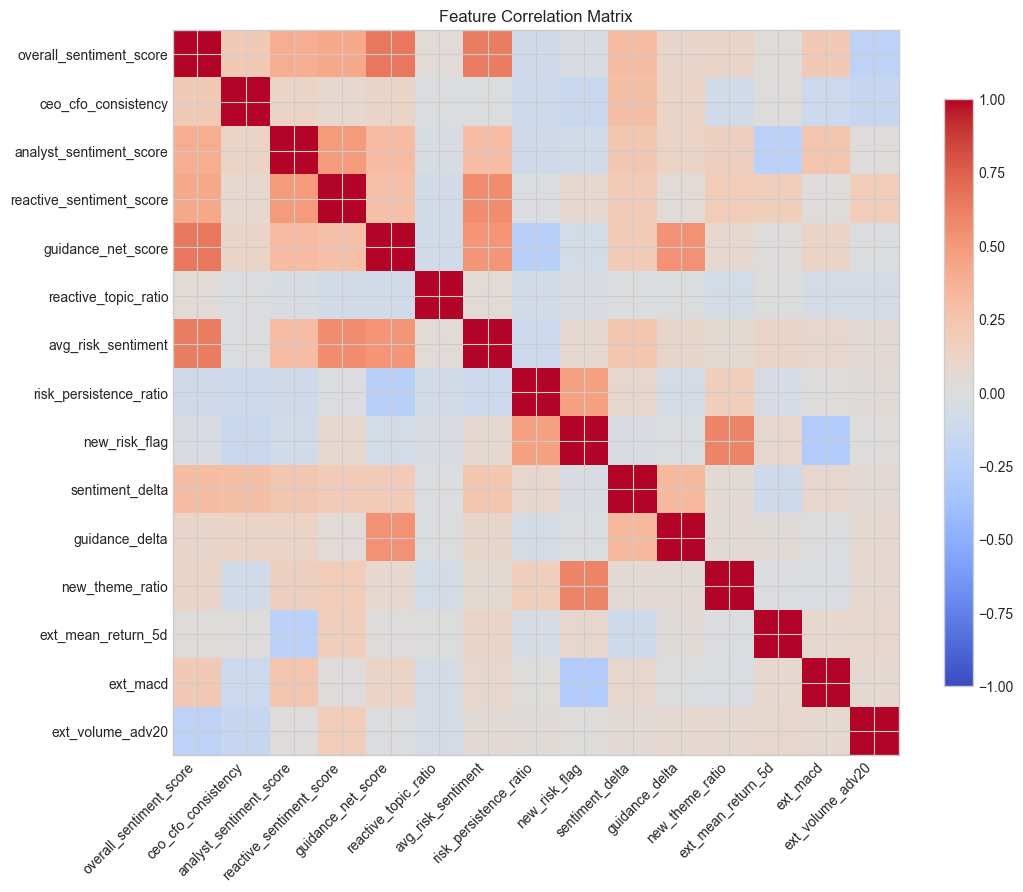

## Most Strongly Correlated Feature Pairs

,feature_1,feature_2,correlation,abs_correlation
4,overall_sentiment_score,guidance_net_score,0.6497,0.6497
6,overall_sentiment_score,avg_risk_sentiment,0.6303,0.6303
131,new_risk_flag,new_theme_ratio,0.6007,0.6007
51,reactive_sentiment_score,avg_risk_sentiment,0.5557,0.5557
70,guidance_net_score,guidance_delta,0.5352,0.5352
66,guidance_net_score,avg_risk_sentiment,0.5225,0.5225
33,analyst_sentiment_score,reactive_sentiment_score,0.4912,0.4912
113,risk_persistence_ratio,new_risk_flag,0.4647,0.4647
3,overall_sentiment_score,reactive_sentiment_score,0.4175,0.4175
2,overall_sentiment_score,analyst_sentiment_score,0.3977,0.3977


In [22]:
feature_corr = train_df[feature_columns].corr()
plot_table_heatmap(feature_corr, "Feature Correlation Matrix", figsize=(11, 9))

corr_pairs = (
    feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
display_section("Most Strongly Correlated Feature Pairs")
display(corr_pairs.sort_values("abs_correlation", ascending=False).head(10))

## 4. Feature-to-Target Correlation

This is the quickest way to show whether any individual feature has a visible linear or rank relationship with the selected target.

,pearson_corr,spearman_corr
new_theme_ratio,0.2712,0.3220
guidance_net_score,0.2253,0.0907
avg_risk_sentiment,0.1836,0.1358
new_risk_flag,0.1547,0.2068
analyst_sentiment_score,0.1508,0.0332
overall_sentiment_score,0.1238,0.0597
risk_persistence_ratio,-0.1226,-0.1317
reactive_sentiment_score,0.0866,0.1128
reactive_topic_ratio,-0.0864,-0.0340
guidance_delta,0.0595,-0.0959


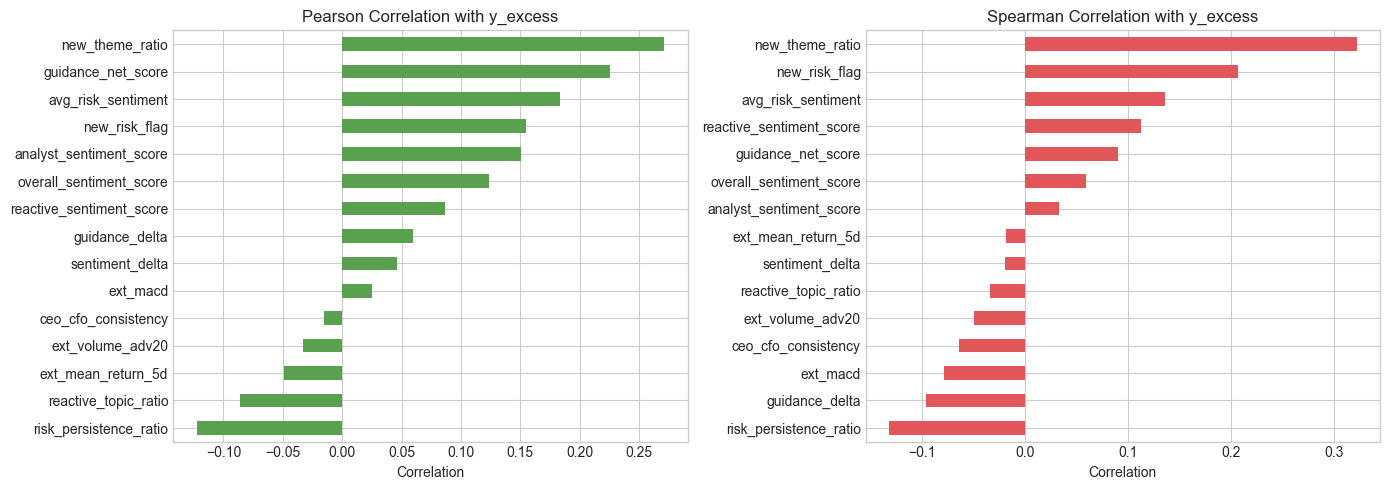

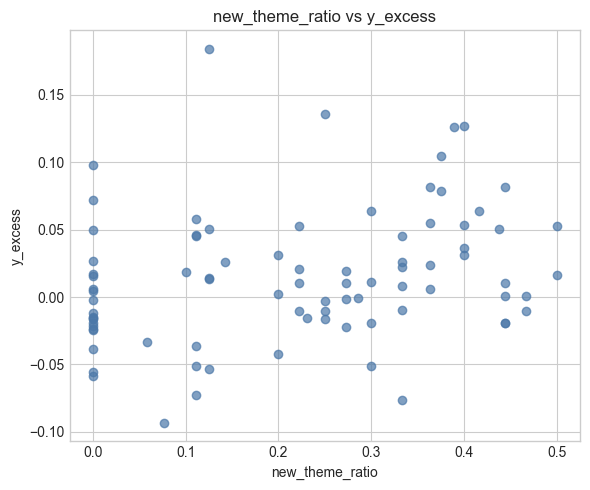

In [23]:
if target_col is None:
    display(Markdown("No usable target column was found in `modeling_table.parquet`."))
else:
    target_corr = pd.DataFrame(
        {
            "pearson_corr": train_df[feature_columns].corrwith(train_df[target_col]),
            "spearman_corr": train_df[feature_columns].corrwith(train_df[target_col], method="spearman"),
        }
    ).sort_values("pearson_corr", key=lambda s: s.abs(), ascending=False)

    display(target_corr)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    target_corr["pearson_corr"].sort_values().plot(kind="barh", ax=axes[0], color="#59A14F")
    axes[0].set_title(f"Pearson Correlation with {target_col}")
    axes[0].set_xlabel("Correlation")

    target_corr["spearman_corr"].sort_values().plot(kind="barh", ax=axes[1], color="#E15759")
    axes[1].set_title(f"Spearman Correlation with {target_col}")
    axes[1].set_xlabel("Correlation")

    plt.tight_layout()
    plt.show()

    top_feature = target_corr.index[0]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(train_df[top_feature], train_df[target_col], alpha=0.7, color="#4C78A8")
    ax.set_title(f"{top_feature} vs {target_col}")
    ax.set_xlabel(top_feature)
    ax.set_ylabel(target_col)
    plt.tight_layout()
    plt.show()

## 5. Saved Predictions

The notebook can also reuse the saved prediction artifacts in `data/predictions/` to show what each model produced and how those predictions compare with realized outcomes.

,model_name,n_rows,n_test_rows,mean_y_pred,std_y_pred,mean_y_true,pearson_pred_true,spearman_pred_true
0,logistic_clf_external_only,44,44,-0.3409,0.6078,0.0000,0.0836,0.0746
1,logistic_clf_nlp_only,44,44,0.2955,0.7947,0.0000,0.1919,0.1985
2,logistic_clf_nlp_plus_external,44,44,0.0909,0.7721,0.0000,-0.0658,-0.0697
3,ridge_reg_external_only,44,44,0.0147,0.0013,-0.0026,0.0675,0.1056
4,ridge_reg_nlp_only,44,44,0.0175,0.0144,-0.0026,0.1022,0.1677
5,ridge_reg_nlp_plus_external,44,44,0.0175,0.0145,-0.0026,0.1130,0.1900
6,xgb_clf_external_only,44,44,0.3409,0.9387,0.0000,-0.1354,-0.1258
7,xgb_clf_nlp_only,44,44,0.3636,0.9423,0.0000,0.0539,0.0539
8,xgb_clf_nlp_plus_external,44,44,0.1818,0.9947,0.0000,0.0000,0.0000
9,xgb_reg_external_only,44,44,0.0142,0.0136,-0.0026,-0.0678,-0.0595


## Sample Prediction Rows: logistic_clf_external_only

,ticker,quarter,call_date,entry_date,exit_date,split,y_true,y_pred,model_name,target_name
0,AMD,Q2-2025,2025-08-05,2025-08-06,2025-08-13,test,1.0000,0.0000,logistic_clf,y_class
1,AMD,Q3-2025,2025-11-04,2025-11-05,2025-11-12,test,0.0000,0.0000,logistic_clf,y_class
2,AMD,Q4-2025,2026-02-03,2026-02-04,2026-02-11,test,1.0000,0.0000,logistic_clf,y_class
3,AVGO,Q3-2025,2025-09-04,2025-09-05,2025-09-12,test,1.0000,0.0000,logistic_clf,y_class
4,AVGO,Q4-2025,2025-12-11,2025-12-12,2025-12-19,test,-1.0000,0.0000,logistic_clf,y_class
5,AVGO,Q1-2026,2026-03-04,2026-03-05,2026-03-12,test,1.0000,0.0000,logistic_clf,y_class
6,BLK,Q2-2025,2025-07-15,2025-07-16,2025-07-23,test,1.0000,-1.0000,logistic_clf,y_class
7,BLK,Q3-2025,2025-10-14,2025-10-15,2025-10-22,test,-1.0000,1.0000,logistic_clf,y_class
8,BLK,Q4-2025,2026-01-15,2026-01-16,2026-01-26,test,-1.0000,-1.0000,logistic_clf,y_class
9,C,Q2-2025,2025-07-15,2025-07-16,2025-07-23,test,1.0000,-1.0000,logistic_clf,y_class


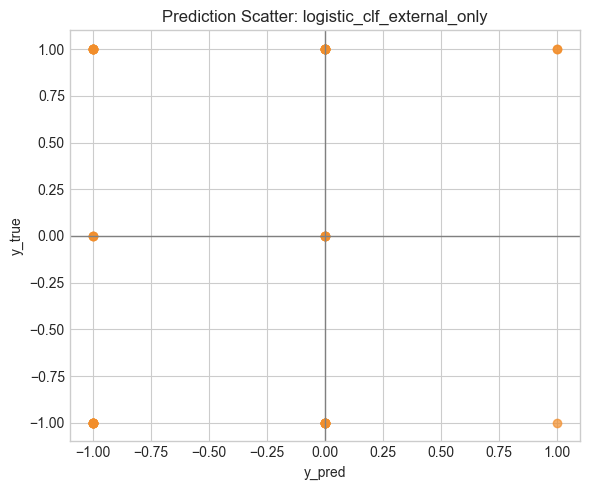

In [24]:
prediction_overview_rows = []
for model_name, pred_df in prediction_map.items():
    row = {
        "model_name": model_name,
        "n_rows": len(pred_df),
        "n_test_rows": int((pred_df["split"] == "test").sum()) if "split" in pred_df.columns else np.nan,
        "mean_y_pred": pred_df["y_pred"].mean() if "y_pred" in pred_df.columns else np.nan,
        "std_y_pred": pred_df["y_pred"].std() if "y_pred" in pred_df.columns else np.nan,
        "mean_y_true": pred_df["y_true"].mean() if "y_true" in pred_df.columns else np.nan,
    }
    if {"y_pred", "y_true"}.issubset(pred_df.columns):
        row["pearson_pred_true"] = pred_df["y_pred"].corr(pred_df["y_true"])
        row["spearman_pred_true"] = pred_df["y_pred"].corr(pred_df["y_true"], method="spearman")
    prediction_overview_rows.append(row)

prediction_overview = pd.DataFrame(prediction_overview_rows).sort_values("model_name")
display(prediction_overview)

if model_metrics_df is not None:
    display_section("Saved Model Metrics")
    display(model_metrics_df)

if prediction_map:
    selected_model = sorted(prediction_map.keys())[0]
    selected_pred_df = prediction_map[selected_model].copy()
    display_section(f"Sample Prediction Rows: {selected_model}")
    sample_cols = [col for col in ["ticker", "quarter", "call_date", "entry_date", "exit_date", "split", "y_true", "y_pred", "model_name", "target_name"] if col in selected_pred_df.columns]
    display(selected_pred_df[sample_cols].head(15))

    if {"y_pred", "y_true"}.issubset(selected_pred_df.columns):
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(selected_pred_df["y_pred"], selected_pred_df["y_true"], alpha=0.7, color="#F28E2B")
        ax.axhline(0, color="gray", linewidth=1)
        ax.axvline(0, color="gray", linewidth=1)
        ax.set_title(f"Prediction Scatter: {selected_model}")
        ax.set_xlabel("y_pred")
        ax.set_ylabel("y_true")
        plt.tight_layout()
        plt.show()

## 6. Backtest and Report Outputs

This section surfaces the saved CSV summaries and PNG figures in `outputs/`, so readers can understand what the downstream pipeline generated without rerunning everything manually.

## Model Comparison Summary

,model_key,feature_set,prediction_name,n_obs,directional_accuracy,information_coefficient,mean_y_pred,std_y_pred,mean_y_true,std_y_true
0,logistic_clf_nlp_only,nlp_only,logistic_clf_nlp_only,44,0.3636,0.1985,0.2955,0.7857,0.0000,0.9045
1,ridge_reg_nlp_plus_external,nlp_plus_external,ridge_reg_nlp_plus_external,44,0.5000,0.1900,0.0175,0.0143,-0.0026,0.0444
2,ridge_reg_nlp_only,nlp_only,ridge_reg_nlp_only,44,0.5227,0.1677,0.0175,0.0143,-0.0026,0.0444
3,xgb_reg_nlp_only,nlp_only,xgb_reg_nlp_only,44,0.5682,0.1282,0.0133,0.0235,-0.0026,0.0444
4,xgb_reg_nlp_plus_external,nlp_plus_external,xgb_reg_nlp_plus_external,44,0.4773,0.0569,0.0152,0.0238,-0.0026,0.0444
5,xgb_clf_nlp_only,nlp_only,xgb_clf_nlp_only,44,0.4318,0.0539,0.3636,0.9315,0.0000,0.9045
6,xgb_clf_nlp_plus_external,nlp_plus_external,xgb_clf_nlp_plus_external,44,0.4091,0.0000,0.1818,0.9833,0.0000,0.9045
7,logistic_clf_nlp_plus_external,nlp_plus_external,logistic_clf_nlp_plus_external,44,0.2500,-0.0697,0.0909,0.7633,0.0000,0.9045


## Long-Short Summary by Model

,model_name,mean_return,volatility,sharpe,hit_rate,avg_win,avg_loss,n_periods
0,ridge_reg,-0.0349,0.0819,-0.4262,0.3333,0.0677,-0.0862,3
1,xgb_reg,-0.0330,0.0812,-0.4062,0.3333,0.0798,-0.0894,3


## Event Backtest Summary by Model

,model_key,feature_set,prediction_name,mean_return,volatility,sharpe,hit_rate,avg_win,avg_loss,directional_accuracy,information_coefficient,n_trades,n_active_days,benchmark_mean_return
0,logistic_clf_nlp_only,nlp_only,logistic_clf_nlp_only,1.0262,0.3613,2.8405,0.3895,0.0174,-0.0168,0.5161,0.1986,31,95,0.3545
1,logistic_clf_nlp_plus_external,nlp_plus_external,logistic_clf_nlp_plus_external,0.3024,0.3367,0.8981,0.4615,0.0149,-0.0147,0.4231,-0.0696,26,78,0.4005
2,ridge_reg_nlp_only,nlp_only,ridge_reg_nlp_only,0.1246,0.4619,0.2698,0.4690,0.0198,-0.0214,0.5227,0.1677,44,113,0.2969
3,ridge_reg_nlp_plus_external,nlp_plus_external,ridge_reg_nlp_plus_external,0.0083,0.4620,0.0179,0.4956,0.0204,-0.0207,0.5000,0.1900,44,113,0.2969
4,xgb_clf_nlp_only,nlp_only,xgb_clf_nlp_only,0.2078,0.4536,0.4580,0.4513,0.0187,-0.0209,0.4318,0.0539,44,113,0.2969
5,xgb_clf_nlp_plus_external,nlp_plus_external,xgb_clf_nlp_plus_external,0.6137,0.4502,1.3632,0.4779,0.0210,-0.0179,0.4091,0.0000,44,113,0.2969
6,xgb_reg_nlp_only,nlp_only,xgb_reg_nlp_only,0.3090,0.4326,0.7142,0.4336,0.0177,-0.0203,0.5682,0.1282,44,113,0.2969
7,xgb_reg_nlp_plus_external,nlp_plus_external,xgb_reg_nlp_plus_external,0.5952,0.4561,1.3050,0.4867,0.0217,-0.0180,0.4773,0.0569,44,113,0.2969


### Long-Short Curve

`outputs\figures\long_short_curve.png` not found.

### Event Equity Curve

`outputs\figures\event_equity_curve.png` not found.

### Model Long-Short Comparison

`outputs\reports\model_report\model_long_short_curves.png` not found.

### Model Event Equity Comparison

Source: `outputs\reports\model_report\model_event_equity_curves.png`

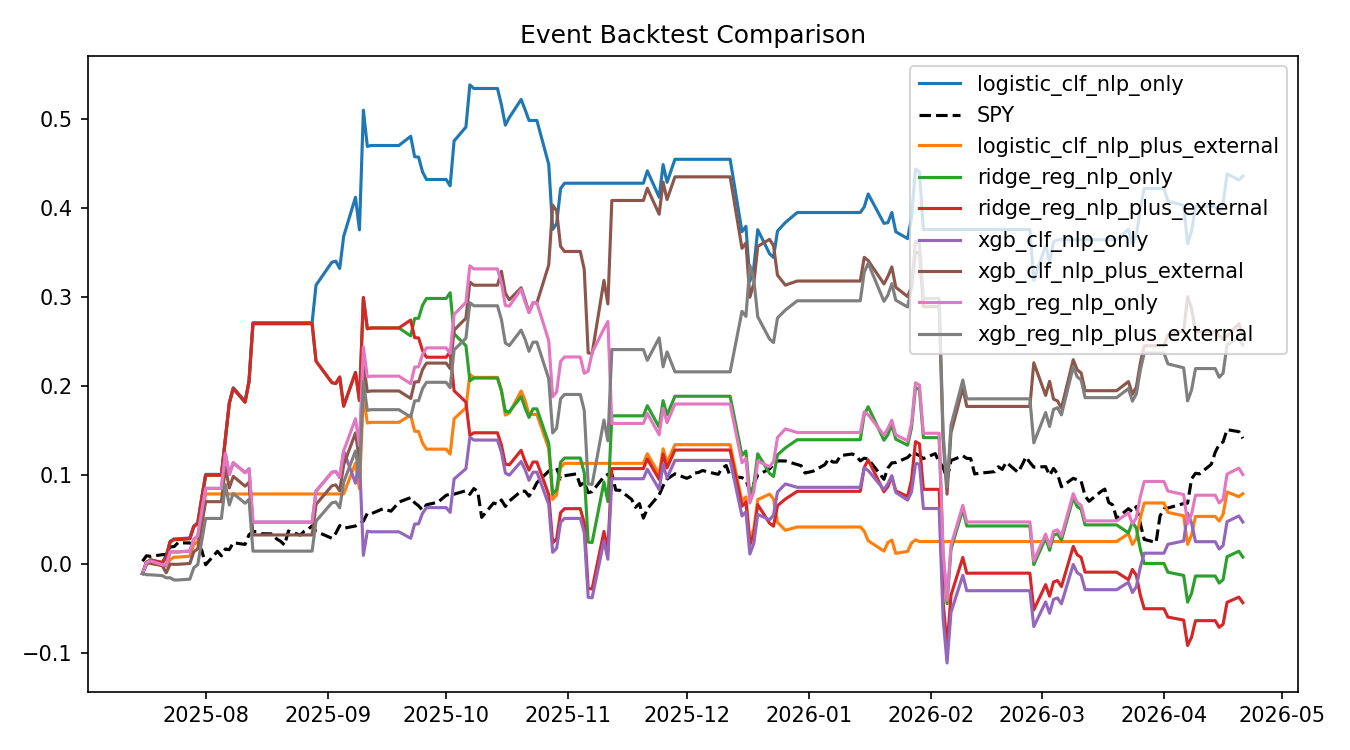

### Model IC Bar Chart

Source: `outputs\reports\model_report\model_ic_bar.png`

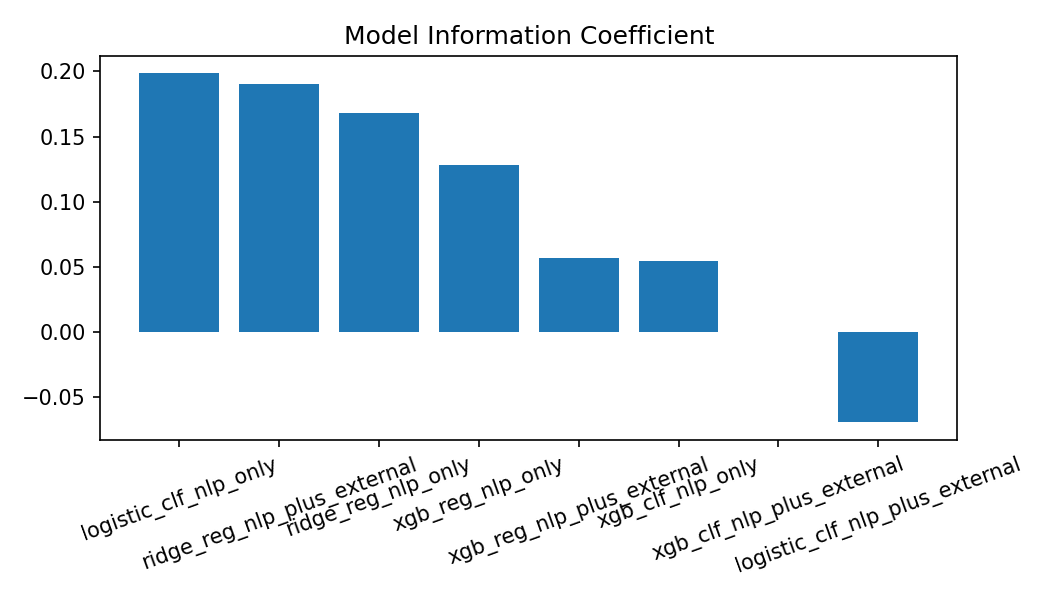

### Model Prediction Scatter

Source: `outputs\reports\model_report\model_prediction_scatter.png`

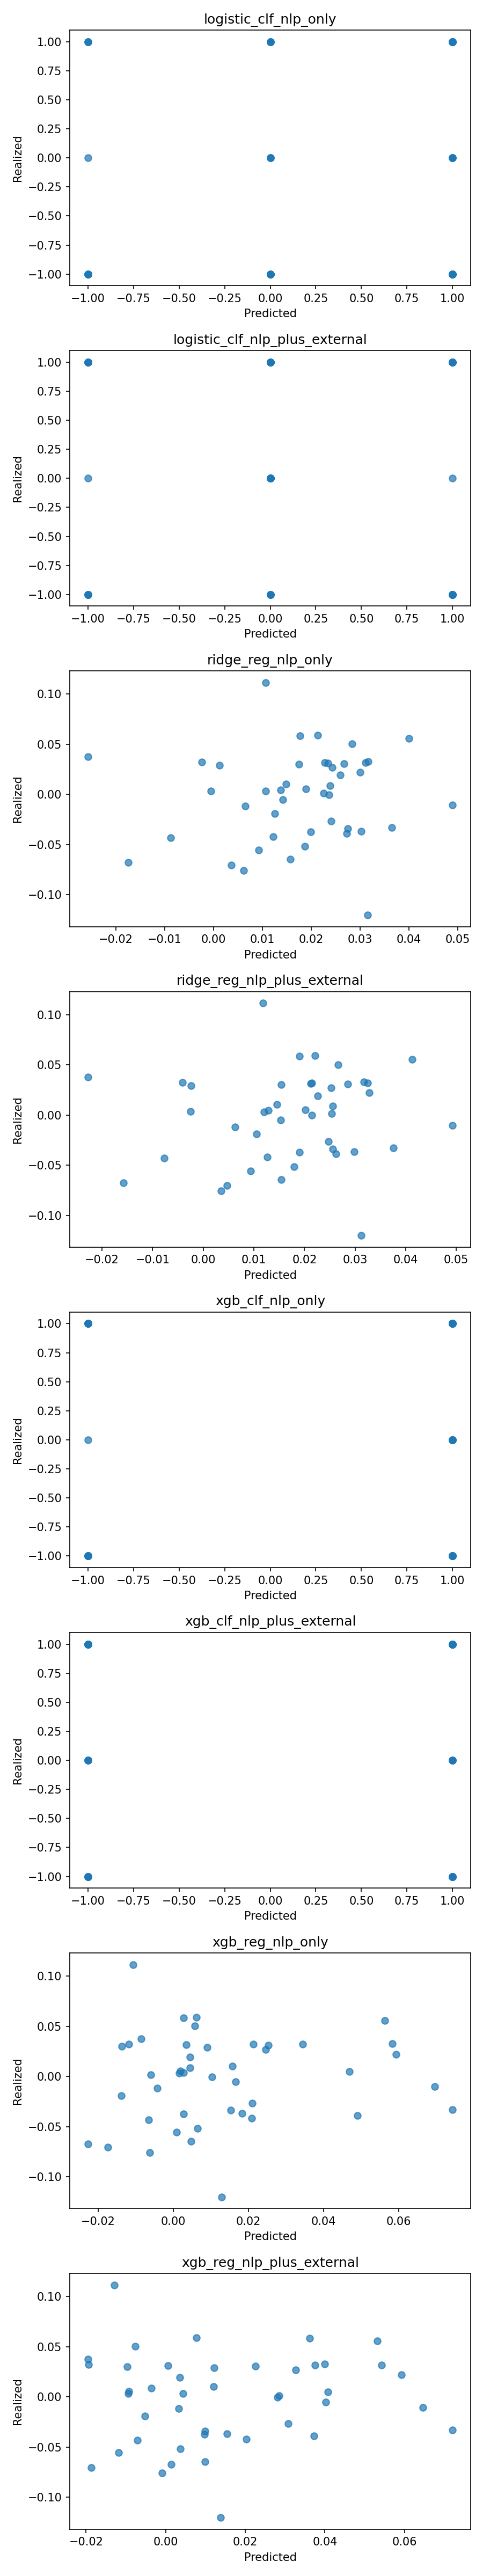

In [25]:
if backtest_summary_df is not None:
    display_section("Backtest Summary Table")
    display(backtest_summary_df)

if backtest_detail_df is not None:
    display_section("Backtest Detail Sample")
    display(backtest_detail_df.head(12))

if model_comparison_df is not None:
    display_section("Model Comparison Summary")
    display(model_comparison_df)

if model_long_short_df is not None:
    display_section("Long-Short Summary by Model")
    display(model_long_short_df)

if model_event_df is not None:
    display_section("Event Backtest Summary by Model")
    display(model_event_df)
show_image_if_exists(outputs_figures_dir / "long_short_curve.png", "Long-Short Curve")
show_image_if_exists(outputs_figures_dir / "event_equity_curve.png", "Event Equity Curve")
show_image_if_exists(report_dir / "model_long_short_curves.png", "Model Long-Short Comparison")
show_image_if_exists(report_dir / "model_event_equity_curves.png", "Model Event Equity Comparison")
show_image_if_exists(report_dir / "model_ic_bar.png", "Model IC Bar Chart")
show_image_if_exists(report_dir / "model_prediction_scatter.png", "Model Prediction Scatter")